           PURPOSE
The primary objective of this notebook is to build a machine learning model capable of identifying fraudulent credit card transactions. By analyzing historical transaction data, we aim to distinguish between legitimate and suspicious activity in real-time to minimize financial losses and protect customer assets.

             Dataset Overview
Source:  From Kaggle  Dataset. link: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data

Features: Contains numerical input variables resulting from PCA transformation (V1-V28), plus 'Time' and 'Amount'.

Target: The Class column, where 0 represents a normal transaction and 1 represents fraud.

IMPORT THE NECESSARY LIBRARIES


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


LOAD THE DATASET

In [3]:
import pandas as pd

# Path to your file
file_path = '/content/drive/My Drive/credit card fraud/creditcard.csv'

# Load the CSV
df = pd.read_csv(file_path)


df.head(5)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
print(df.dtypes)
print(df.isnull().sum())

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


CLASS DISTRIBUTION

In [7]:
proportion = df['Class'].value_counts(normalize=True)
print(proportion * 100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [8]:
bin_size = 10000

df['Time_bin'] = df['Time'] // bin_size  # round it down to the nearest integer.
df['Time_bin'] = df['Time_bin'].astype(int)

agg = df.groupby('Time_bin')['Class'].agg(['count', 'sum']).reset_index()
agg.rename(columns = {'count': 'Total_Tx', 'sum': 'Fraud_Tx'}, inplace=True)

agg['Fraud_rate'] = agg['Fraud_Tx'] / agg['Total_Tx']

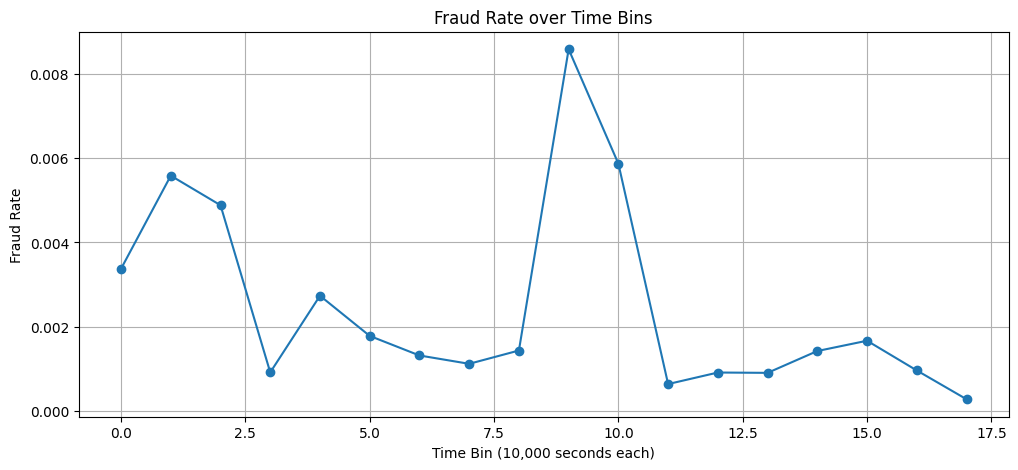

In [9]:
plt.figure(figsize=(12,5))
plt.plot(agg['Time_bin'], agg['Fraud_rate'], marker='o')
plt.xlabel('Time Bin (10,000 seconds each)')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate over Time Bins')
plt.grid(True)
plt.show()

In [10]:
agg.tail(4)

,Time_bin,Total_Tx,Fraud_Tx,Fraud_rate
14,14,23922,34,0.001421
15,15,22212,37,0.001666
16,16,19790,19,0.000960
17,17,3612,1,0.000277


In [11]:
df.tail(4)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Time_bin
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,17
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,17
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,17
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0,17


EDA - EXPOLATORY DATA ANALYSIS

(PCA)Components that show the largest deviations for fraud vs normal transactions

In [12]:

pca_cols = [f'V{i}' for i in range(1, 29)]

#compute mean and std for normal transactions(class = 0)
normal_stats = df[df['Class'] ==0][pca_cols].agg(['mean', 'std']).T

normal_stats.rename(columns = {'mean': 'Normal_mean', 'std': 'Normal_std'}, inplace=True)

#compute mean & std for fraud transactions(class=1)
fraud_stats = df[df['Class'] ==1][pca_cols].agg(['mean', 'std']).T
fraud_stats.rename(columns = {'mean': 'Fraud_mean', 'std': 'Fraud_std'},inplace=True)

#merge stats into one table for comparison
stats = normal_stats.join(fraud_stats)
stats['Mean_diff'] = abs(stats['Fraud_mean'] - stats['Normal_mean'])
stats['Std_diff'] = abs(stats['Fraud_std'] - stats['Normal_std'])

#sort by largest difference in means

stats.sort_values(by=['Mean_diff'], ascending=False, inplace=True)
stats.head(10)

,Normal_mean,Normal_std,Fraud_mean,Fraud_std,Mean_diff,Std_diff
V3,0.012171,1.459429,-7.033281,7.110937,7.045452,5.651508
V14,0.012064,0.897007,-6.971723,4.278940,6.983787,3.381933
V17,0.011535,0.749457,-6.665836,6.970618,6.677371,6.221161
V12,0.010832,0.945939,-6.259393,4.654458,6.270225,3.708519
V10,0.009824,1.044204,-5.676883,4.897341,5.686707,3.853137
V7,0.009637,1.178812,-5.568731,7.206773,5.578368,6.027961
V1,0.008258,1.929814,-4.771948,6.783687,4.780206,4.853873
V4,-0.007860,1.399333,4.542029,2.873318,4.549889,1.473984
V16,0.007164,0.844772,-4.139946,3.865035,4.147110,3.020263
V11,-0.006576,1.003112,3.800173,2.678605,3.806749,1.675493


V1 shows a large separation between fraud and normal transactions: frauds are concentrated in the negative tail, with a wider spread. V1 is therefore highly predictive of abnormal behavior and useful for early anomaly detection.

In [13]:
v1_stats = stats.loc['V1']

print(v1_stats)

Normal_mean    0.008258
Normal_std     1.929814
Fraud_mean    -4.771948
Fraud_std      6.783687
Mean_diff      4.780206
Std_diff       4.853873
Name: V1, dtype: float64


In [14]:
v1_normal = df[df['Class'] ==0]['V1']
v1_fraud = df[df['Class'] ==1]['V1']

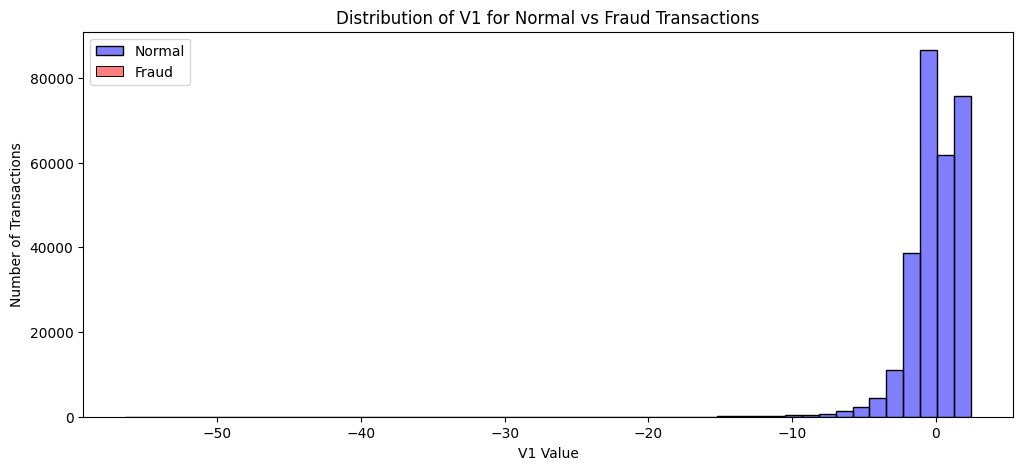

In [15]:

plt.figure(figsize=(12,5))
sns.histplot(v1_normal, bins=50, color='blue', alpha=0.5, label='Normal')
sns.histplot(v1_fraud, bins=50, color='red', alpha=0.5, label='Fraud')
plt.xlabel('V1 Value')
plt.ylabel('Number of Transactions')
plt.title('Distribution of V1 for Normal vs Fraud Transactions')
plt.legend()
plt.show()


/tmp/ipython-input-2338839061.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Class', x='V1', data=df, orient='h', palette=['blue', 'red'])


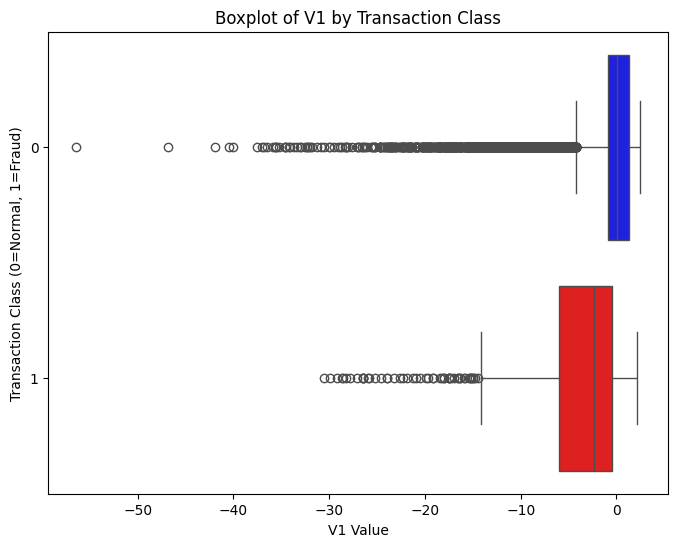

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(y='Class', x='V1', data=df, orient='h', palette=['blue', 'red'])
plt.ylabel('Transaction Class (0=Normal, 1=Fraud)')
plt.xlabel('V1 Value')
plt.title('Boxplot of V1 by Transaction Class')
plt.show()


How extreme are fraud values compared to normal?

In [17]:
normal_mean = stats.loc['V1', 'Normal_mean']
normal_std = stats.loc['V1', 'Normal_std']

df['V1_zscore_vs_normal'] = (df['V1'] - normal_mean) / normal_std
df.sort_values('V1_zscore_vs_normal').head(10)[
    ['V1', 'V1_zscore_vs_normal','Amount' ,'Class']
]

,V1,V1_zscore_vs_normal,Amount,Class
39769,-56.407510,-29.233784,1201.83,0
220212,-46.855047,-24.283845,303.80,0
224569,-41.928738,-21.731107,200.00,0
234519,-40.470142,-20.975285,157.43,0
206255,-40.042537,-20.753707,1676.60,0
220090,-37.558067,-19.466293,5964.95,0
206228,-37.054295,-19.205246,1676.60,0
58465,-36.802320,-19.074676,19656.53,0
145022,-36.510583,-18.923502,102.00,0
231454,-35.905105,-18.609753,3552.96,0


When V1 is extremely abnormal, how do normal and fraud transactions differ?

FINDINGS

V1 captures the dominant transaction behavior pattern. Fraudulent transactions are strongly shifted into the negative tail and exhibit much larger spread. However, extreme V1 values also occur in legitimate transactions, making V1 a strong anomaly indicator but insufficient as a standalone fraud signal



In [18]:
# Define extreme threshold
threshold = -10

extreme_v1 = df[df['V1_zscore_vs_normal'] < threshold]

# Split by class
extreme_normal = extreme_v1[extreme_v1['Class'] == 0]
extreme_fraud  = extreme_v1[extreme_v1['Class'] == 1]

len(extreme_normal), len(extreme_fraud)


(150, 27)

Component v3 FINDINGS

V3 is one of the strongest fraud-separating components -  fraud transactions are massively shifted into the negative direction and exhibit extremely high variability, while normal transactions remain tightly centered around zero.



In [19]:
v3_stats = stats.loc['V3']

v3_stats

,V3
Normal_mean,0.012171
Normal_std,1.459429
Fraud_mean,-7.033281
Fraud_std,7.110937
Mean_diff,7.045452
Std_diff,5.651508


In [20]:
# Select components + real features
cols = ['V1','V2','V3','V14','V17','Amount','Time','Class']  # pick top informative components
corr_df = df[cols].corr()

corr_df


,V1,V2,V3,V14,V17,Amount,Time,Class
V1,1.000000e+00,4.135835e-16,-1.227819e-15,-5.020280e-16,-3.879840e-16,-0.227709,0.117396,-0.101347
V2,4.135835e-16,1.000000e+00,3.243764e-16,-1.730566e-16,-2.685296e-16,-0.531409,-0.010593,0.091289
V3,-1.227819e-15,3.243764e-16,1.000000e+00,4.739859e-16,7.614712e-16,-0.210880,-0.419618,-0.192961
V14,-5.020280e-16,-1.730566e-16,4.739859e-16,1.000000e+00,1.162529e-15,0.033751,-0.098757,-0.302544
V17,-3.879840e-16,-2.685296e-16,7.614712e-16,1.162529e-15,1.000000e+00,0.007309,-0.073297,-0.326481
Amount,-2.277087e-01,-5.314089e-01,-2.108805e-01,3.375117e-02,7.309042e-03,1.000000,-0.010596,0.005632
Time,1.173963e-01,-1.059333e-02,-4.196182e-01,-9.875682e-02,-7.329721e-02,-0.010596,1.000000,-0.012323
Class,-1.013473e-01,9.128865e-02,-1.929608e-01,-3.025437e-01,-3.264811e-01,0.005632,-0.012323,1.000000


CORRELATION MATRIX

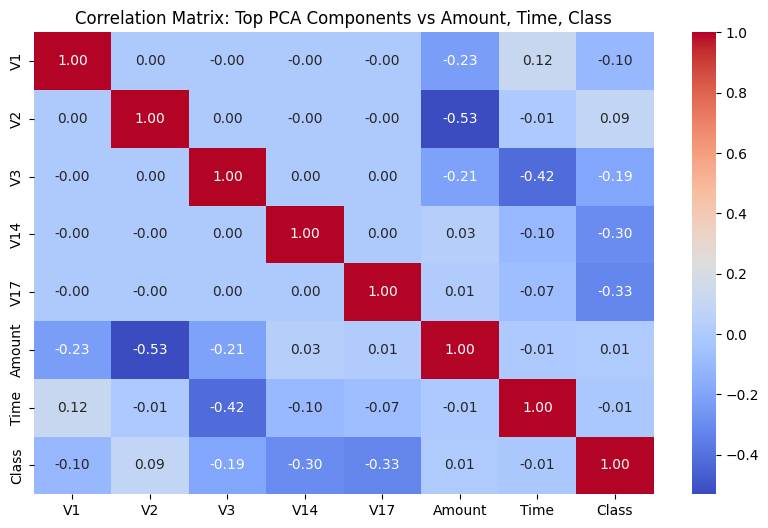

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix: Top PCA Components vs Amount, Time, Class")
plt.show()


PREPROCESSING THE DATASET

In [22]:
df.head(1)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Time_bin,V1_zscore_vs_normal
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0,-0.70891


Since the Amount and Time features are not pre-scaled like the PCA-transformed variables (V1–V28), we must standardize them to ensure their large numerical ranges do not disproportionately bias the model's weight updates or distance calculations.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['Amount', 'Time']] = scaler.fit_transform(df[['Amount', 'Time']])

In [24]:
y = df['Class']
X = df.drop(columns=['Class', 'V1_zscore_vs_normal', 'Time_bin'])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)


In [25]:
X_train.shape, X_test.shape

((199364, 30), (85443, 30))

Class Imbalance

our dataset suffers from a severe class imbalance, with fraudulent transactions being far less frequent than legitimate ones. This code creates a count plot to visualize the distribution of classes in a dataset.

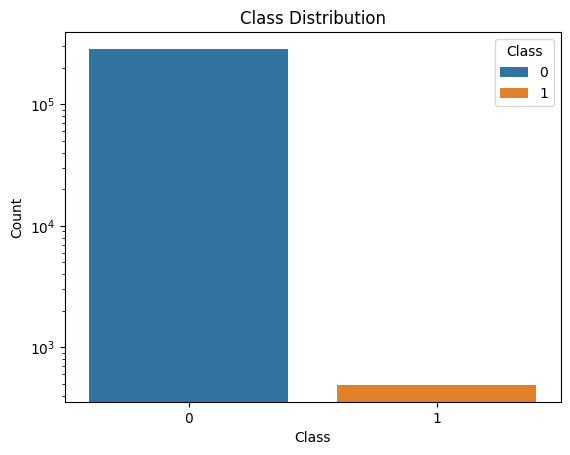

In [26]:
# Plot class distribution
sns.countplot(x='Class', data=df, hue='Class', hue_order=[0, 1])

# Set title and labels
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

# Set y-axis to logarithmic scale
plt.yscale('log')

# Show plot
plt.show()


Compute class weights

We compute class weights to balance the influence of our data by assigning a higher penalty to errors on the minority class (fraud). This ensures that the model treats each fraudulent transaction as significantly more important than a legitimate one, preventing the algorithm from simply ignoring fraud due to its rarity in the dataset

In [27]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
class_weights = compute_class_weight(
    class_weight='balanced', classes=classes, y=y_train
)

class_weights = dict(zip(classes, class_weights))
class_weights

{np.int64(0): np.float64(0.5008642347502763),
 np.int64(1): np.float64(289.7732558139535)}

Logistic regression

We establish a baseline model to create a performance benchmark and identify which features contribute the least to predictive power. By analyzing the baseline's feature importance, we can prune redundant or noisy variables

In [28]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    class_weight=class_weights,
    max_iter = 1000,
    n_jobs=-1,
    random_state=42
)

log_reg.fit(X_train, y_train)

LogisticRegression(class_weight={np.int64(0): np.float64(0.5008642347502763),
                                 np.int64(1): np.float64(289.7732558139535)},
                   max_iter=1000, n_jobs=-1, random_state=42)

In [29]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df.tail(10)

,Feature,Coefficient
7,V7,-0.633502
0,Time,-0.681428
9,V9,-0.783448
27,V27,-0.843760
16,V16,-0.917728
17,V17,-1.057093
20,V20,-1.058282
12,V12,-1.167605
14,V14,-1.428672
10,V10,-1.666629


Pruning

To optimize the model, we prune features with a coefficient of less than 0.3, systematically removing variables that show a weak relationship with the target class to reduce noise and improve computational efficiency


In [30]:
THRESHOLD = 0.3

#select strong features
selected_features = coef_df[coef_df['Coefficient'].abs() >= THRESHOLD]

#extract feature names
keep_features = selected_features['Feature'].tolist()

print(len(keep_features))
print(keep_features)

#transform dataset
X_train_pruned = X_train[keep_features]
X_test_pruned = X_test[keep_features]

20
['Amount', 'V4', 'V1', 'V22', 'V5', 'V11', 'V21', 'V19', 'V13', 'V8', 'V7', 'Time', 'V9', 'V27', 'V16', 'V17', 'V20', 'V12', 'V14', 'V10']


In [31]:
model_pruned = LogisticRegression(
    class_weight=class_weights,
    max_iter = 1000,
)

model_pruned.fit(X_train_pruned, y_train)

LogisticRegression(class_weight={np.int64(0): np.float64(0.5008642347502763),
                                 np.int64(1): np.float64(289.7732558139535)},
                   max_iter=1000)

Thresholds - using arbitrary numbers


In [32]:
y_proba = model_pruned.predict_proba(X_test_pruned)[:, 1]


#define thresholds
LOW = 0.2
MED = 0.4
HIGH = 0.7

#Decision function
def decision(p):
  if p < LOW:
    return "APPROVE"
  elif p < MED:
    return "MONITOR"
  elif p < HIGH:
    return "REVIEW"
  else:
    return "BLOCK"

#Apply decisions
decisions = [decision(p) for p in y_proba]


#Build results table

results = X_test_pruned.copy()
results['fraud_probability'] = y_proba
results['decision'] = decisions
results['true_class'] = y_test.values

In [33]:
results.head

<bound method NDFrame.head of           Amount        V4        V1       V22        V5       V11       V21  \
186882 -0.203701 -1.102759 -2.537331 -2.167329 -2.105725 -1.612586  4.328165   
165754 -0.316167  0.417324 -0.250839  0.499501  1.204079  0.244248  0.133048   
235285  2.445431  1.670652  0.568980 -0.760732 -1.128945  0.520022  0.318037   
101271 -0.293298  0.381772  1.328892 -1.148959  0.238490 -1.431070 -0.379270   
5832   -0.284262  1.030033  1.124863 -0.195607 -0.891116  0.334222 -0.216512   
...          ...       ...       ...       ...       ...       ...       ...   
64725  -0.349551 -2.473986 -1.808185 -0.020080  2.185095 -0.237233 -1.441887   
16688  -0.298296  0.860048 -0.442905  0.271637  1.210872  0.305707 -0.154031   
183868 -0.057371 -1.131369  2.092418 -0.274004 -0.197801  0.652112 -0.008183   
45011  -0.345313  0.329036  1.293234 -1.128741  0.034958  0.178210 -0.340111   
150527 -0.289660 -0.702993  2.214016 -0.224863 -0.184492  0.177157 -0.182835   

             V19       V13        V8  ...       V27       V16       V17  \
186882 -0.789047  0.406871 -3.543314  ... -0.177157 -0.947788  0.557331   
165754  0.604366 -0.475202 -0.133535  ...  0.143897 -0.621563 -0.397771   
235285 -0.555301 -2.279548  0.161493  ... -0.096970  0.875849 -0.824311   
101271  0.329519 -0.188827 -0.079962  ... -0.031732  0.919639 -0.475997   
5832   -0.600662  1.066235  0.163280  ...  0.001142 -0.129612  0.870825   
...          ...       ...       ...  ...       ...       ...       ...   
64725  -0.496123 -0.311592 -1.860286  ... -0.701644  0.885217 -1.077630   
16688   1.474090  0.398728 -0.176599  ... -0.013664 -0.876496 -0.290372   
183868  1.200952 -0.093172 -0.119017  ... -0.056360  1.253814 -0.175598   
45011   0.546941 -2.064189  0.153076  ... -0.044116  1.127827 -0.542123   
150527  0.677552  2.227428 -0.352428  ... -0.057635  0.547428  1.140502   

             V20       V12       V14       V10  fraud_probability  decision  \
186882 -1.959611  0.635855  0.854371  0.112724           0.001522   APPROVE   
165754 -0.128120  0.418555  0.658159 -0.261170           0.048379   APPROVE   
235285  1.039287 -0.251312  0.893064  0.099172           0.068366   APPROVE   
101271 -0.050933 -0.578758 -0.236694 -0.267319           0.037225   APPROVE   
5832   -0.196966 -2.299609  1.177166 -0.641129           0.091263   APPROVE   
...          ...       ...       ...       ...                ...       ...   
64725   0.745500  0.013435  0.259128 -0.099751           0.002424   APPROVE   
16688   0.310200  0.534272 -0.408602  0.594082           0.107691   APPROVE   
183868  0.120353 -0.084962  0.216543  0.946786           0.002448   APPROVE   
45011  -0.186409 -0.742165  0.318913 -0.041285           0.078429   APPROVE   
150527 -0.033153 -2.676488  1.177296  0.349829           0.003831   APPROVE   

        true_class  
186882           0  
165754           0  
235285           0  
101271           0  
5832             0  
...            ...  
64725            0  
16688            0  
183868           0  
45011            0  
150527           0  

[85443 rows x 23 columns]>

In [34]:
review_cases = results[results["decision"] == "REVIEW"]
review_cases.head(4)

,Amount,V4,V1,V22,V5,V11,V21,V19,V13,V8,...,V27,V16,V17,V20,V12,V14,V10,fraud_probability,decision,true_class
200304,-0.349231,0.010040,-1.026187,0.210913,0.838896,-0.391658,0.136952,-0.153702,-1.698778,0.251694,...,-0.070535,0.749110,2.201791,-0.100022,-1.472184,-1.952265,-2.229230,0.520103,REVIEW,0
233012,-0.349231,1.482628,2.044872,-0.057671,0.871095,-0.897571,-0.066923,-0.399281,-2.095002,-0.226146,...,-0.011820,-0.130012,1.089316,-0.354499,-0.967734,-0.638418,-0.304963,0.500275,REVIEW,0
103032,-0.293258,2.383956,-0.453328,0.118307,0.297206,-0.263429,-0.031045,-0.787467,0.975451,-0.038226,...,0.082435,0.267063,0.956323,0.018896,0.393998,-1.879290,-0.528400,0.422216,REVIEW,0
73958,-0.322924,1.531289,-0.767161,-0.118022,0.619906,0.273187,-0.044292,-1.014949,-1.477023,0.294845,...,0.061516,1.002156,0.126571,-0.209674,-0.364367,-1.064041,-0.502749,0.421457,REVIEW,0


In [35]:
block_cases = results[results["decision"] == "BLOCK"]
block_cases.head(10)
#

,Amount,V4,V1,V22,V5,V11,V21,V19,V13,V8,...,V27,V16,V17,V20,V12,V14,V10,fraud_probability,decision,true_class
5909,-0.349231,0.045415,-0.751080,-0.281672,1.806495,3.434154,-0.165446,-2.760684,0.788478,-0.106696,...,0.095917,1.408803,2.914537,-0.286981,-2.568197,-1.834271,-2.731947,0.858575,BLOCK,0
147247,1.276750,4.983313,-0.414060,-0.597100,0.532468,0.309489,-0.893649,1.063430,1.077233,-1.495876,...,-0.458366,0.506890,1.872550,-0.512223,-1.115917,-4.045450,1.433660,0.988359,BLOCK,0
43204,0.072767,9.194935,-15.140450,0.341678,-13.466163,4.828235,3.147428,3.183559,1.998126,10.075254,...,-2.458680,-10.615745,-21.017898,-1.691482,-11.058401,-8.592047,-13.009403,1.000000,BLOCK,1
229712,-0.348512,6.009415,0.908637,-0.397435,0.216656,2.941190,0.407260,-1.563740,-1.989529,0.338527,...,0.648705,-1.952290,-2.892555,0.241921,-6.151362,-9.150951,-4.063098,1.000000,BLOCK,1
275292,-0.350191,4.319208,1.951197,-0.596671,2.044940,0.160615,-0.269758,-1.903690,0.977854,-0.301547,...,-0.002608,1.762264,2.849086,-0.073444,-0.413992,-4.436282,-0.418515,0.978270,BLOCK,0
187640,-0.349231,3.768484,-3.665272,0.699967,3.949063,-0.261669,-0.377274,-1.682899,-0.800975,-1.030901,...,-0.799890,1.066142,1.488288,-1.749836,-1.665468,-2.747243,0.754537,0.978021,BLOCK,0
20946,11.039077,4.587349,-4.400160,-1.266522,-2.219460,1.564950,1.811066,-2.226800,-0.203051,-0.564297,...,-0.551804,0.335967,-0.049185,5.542785,0.567561,1.526948,-0.492532,0.873822,BLOCK,0
130347,-0.347272,1.530860,1.281877,-0.597520,1.078398,0.375183,-0.242949,-0.650137,-0.053956,-0.354864,...,0.039199,1.181161,2.526509,-0.019616,-0.646812,-3.407618,-1.549679,0.908646,BLOCK,0
19651,-0.341275,0.573202,0.255293,-0.435928,3.475331,0.890828,-0.213447,-0.011521,-0.229042,0.894684,...,-0.127166,1.205630,2.377454,0.122600,-0.774094,-3.311204,-1.015619,0.908194,BLOCK,0
218442,0.429036,2.335045,-6.352337,1.226745,-0.809555,2.942939,1.325218,0.718332,-0.433094,2.239089,...,0.910591,-5.104480,-7.925389,0.186898,-4.125722,-3.518131,-5.165331,1.000000,BLOCK,1


  Cost Optimized thresholding

  To further refine our detection, we implement cost-optimized thresholding by shifting the decision boundary away from the default 0.5. By calculating the specific financial costs associated with 'False Negatives' (missed fraud) versus 'False Positives' (false alarms), we identify the optimal threshold.

In [36]:
lr_probs = model_pruned.predict_proba(X_test_pruned)[:, 1]

In [37]:
#Define the costs

C_FP = 50 # cost of blocking a normal transaction
C_FN = 500 #cost of missing a fraud transaction

thresholds = np.linspace(0, 1, 101)
lr_costs = []

for t in thresholds:
    # Vectorized decisions
    preds = (lr_probs >= t).astype(int)

    # Fast sum of errors
    fp = np.sum((y_test == 0) & (preds == 1))
    fn = np.sum((y_test == 1) & (preds == 0))

    lr_costs.append((fp * C_FP) + (fn * C_FN))

optimal_threshold = thresholds[np.argmin(lr_costs)]
print(f"Optimal LR Threshold: {optimal_threshold}")


Optimal LR Threshold: 0.98


In [38]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score


lr_preds = (lr_probs >= optimal_threshold).astype(int)

cm = confusion_matrix(y_test, lr_preds)
report = classification_report(y_test, lr_preds)

print(f"Threshold: {optimal_threshold}")
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)

print(f"ROC-AUC: {roc_auc_score(y_test, lr_probs):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, lr_probs):.4f}")


Threshold: 0.98
Confusion Matrix:
[[85200    95]
 [   25   123]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.56      0.83      0.67       148

    accuracy                           1.00     85443
   macro avg       0.78      0.91      0.84     85443
weighted avg       1.00      1.00      1.00     85443

ROC-AUC: 0.9657
PR-AUC: 0.7019


Decision function based on thresholds

In [39]:
# Assign decisions using the optimal threshold
results["decision"] = results["fraud_probability"].apply(
    lambda p: "BLOCK" if p >= optimal_threshold else "APPROVE"
)

# Quick check of counts
print(results["decision"].value_counts())

#  Optional: see a few transactions
print(results[["fraud_probability", "decision", "true_class"]].head(5))


decision
APPROVE    85225
BLOCK        218
Name: count, dtype: int64
        fraud_probability decision  true_class
186882           0.001522  APPROVE           0
165754           0.048379  APPROVE           0
235285           0.068366  APPROVE           0
101271           0.037225  APPROVE           0
5832             0.091263  APPROVE           0


In [40]:
# Filter only blocked transactions
blocked_transactions = results[results["decision"] == "BLOCK"]

# Quick inspection
blocked_transactions.head(10)   # first 10 blocked transactions

# Or just see the indices and fraud probabilities
#print(blocked_transactions[["fraud_probability", "true_class"]])


,Amount,V4,V1,V22,V5,V11,V21,V19,V13,V8,...,V27,V16,V17,V20,V12,V14,V10,fraud_probability,decision,true_class
147247,1.276750,4.983313,-0.414060,-0.597100,0.532468,0.309489,-0.893649,1.063430,1.077233,-1.495876,...,-0.458366,0.506890,1.872550,-0.512223,-1.115917,-4.045450,1.433660,0.988359,BLOCK,0
43204,0.072767,9.194935,-15.140450,0.341678,-13.466163,4.828235,3.147428,3.183559,1.998126,10.075254,...,-2.458680,-10.615745,-21.017898,-1.691482,-11.058401,-8.592047,-13.009403,1.000000,BLOCK,1
229712,-0.348512,6.009415,0.908637,-0.397435,0.216656,2.941190,0.407260,-1.563740,-1.989529,0.338527,...,0.648705,-1.952290,-2.892555,0.241921,-6.151362,-9.150951,-4.063098,1.000000,BLOCK,1
218442,0.429036,2.335045,-6.352337,1.226745,-0.809555,2.942939,1.325218,0.718332,-0.433094,2.239089,...,0.910591,-5.104480,-7.925389,0.186898,-4.125722,-3.518131,-5.165331,1.000000,BLOCK,1
184541,-0.350151,4.662107,1.919986,-0.701382,2.927430,2.966293,-0.275728,-2.351759,0.128162,-0.368714,...,0.015611,3.388326,5.324814,-0.005192,-1.003854,-7.576329,-1.645502,0.999918,BLOCK,0
153823,-0.344114,12.114672,-19.641857,3.318178,-14.898113,4.971249,-8.228874,1.422632,-1.071443,-11.919639,...,-4.126746,-8.582309,-13.806568,3.834649,-12.686308,-7.383370,-18.913243,1.000000,BLOCK,1
247348,-0.353229,4.727085,1.886311,-0.840727,2.487961,3.048973,-0.298241,-2.452054,-1.131161,-0.293231,...,0.010192,3.303061,5.284353,-0.104855,-1.441407,-7.044750,-1.499583,0.999874,BLOCK,0
42549,-0.000478,8.344392,-5.314173,0.862996,-5.718008,7.674534,2.331466,2.992554,0.526939,3.404129,...,2.245091,-12.391346,-22.541652,1.150017,-14.296091,-15.445026,-11.435624,1.000000,BLOCK,1
13394,0.006558,5.964859,-9.925356,-0.794712,-8.605175,8.464554,1.541435,1.639382,0.742861,6.878428,...,1.884470,-8.789375,-15.095898,1.422021,-13.191108,-10.886933,-10.301635,1.000000,BLOCK,0
19760,31.149371,7.730844,-14.191832,-4.067605,-8.285413,1.288000,4.696025,-2.979730,1.073272,-1.502509,...,-1.387145,0.487620,0.510969,15.815051,1.688777,1.595401,-3.790097,0.997646,BLOCK,0


In [41]:
# Count how many blocked are actual fraud vs normal
blocked_transactions["true_class"].value_counts()


,count
true_class,
1,123
0,95


XGBOOST

We use XGBoost (Extreme Gradient Boosting) as our advanced model to capture complex, non-linear relationships within the data.

In [42]:
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

To maximize the model's performance, we perform Hyperparameter Tuning using Randomized Search. By testing 30 random combinations of settings—such as tree depth, learning rate, and subsampling—across 3-fold cross-validation, we move beyond default configurations to find the optimal balance that specifically maximizes the F1-Score for fraud detection.

In [43]:
# Initialize base model
xgb_model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='aucpr',
    scale_pos_weight=class_weights[1] / class_weights[0] # handle imbalance
)

# Define hyperparameter space
param_dist = {
    'n_estimators': randint(50, 300),          # number of trees
    'max_depth': randint(3, 10),               # depth of each tree
    'learning_rate': uniform(0.01, 0.3),      # step size
    'subsample': uniform(0.6, 0.4),           # fraction of data per tree
    'colsample_bytree': uniform(0.6, 0.4),    # fraction of features per tree
    'gamma': uniform(0, 5),                    # minimum loss reduction to make split
    'min_child_weight': randint(1, 10)         # min sum of instance weight in leaf
}

# Setup Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=30,             # number of random combinations to try
    scoring='f1',          # prioritize fraud detection
    cv=3,                  # 3-fold cross-validation
    verbose=2,
    n_jobs=-1,             # use all CPU cores
    random_state=42
)

# Fit on training data
random_search.fit(X_train_pruned, y_train)

# Best parameters
print("Best parameters found:", random_search.best_params_)


Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:33:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found: {'colsample_bytree': np.float64(0.7297380084021096), 'gamma': np.float64(0.6104397735033668), 'learning_rate': np.float64(0.11688935142309247), 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 178, 'subsample': np.float64(0.6911740650167767)}


Calibration

We use probability calibration to ensure that the model’s predicted probability scores (e.g., 0.8) actually reflect the real-world likelihood of fraud (80%). This adjustment is crucial for fraud detection because it allows us to trust the model’s confidence levels when setting automated thresholds

In [44]:
from sklearn.calibration import CalibratedClassifierCV
import numpy as np

# Use this to access the parameters you already tuned
best_params = random_search.best_params_
#best_params["scale_pos_weight"] = class_weights[1] / class_weights[0]

# 1. Use the base template model, not the already fitted 'final_model'
base_xgb_model = xgb.XGBClassifier(eval_metric="aucpr",**best_params)

# 2. Use cv=5 (or another number) on the TRAINING set to learn the calibration
calibrated_model_cv = CalibratedClassifierCV(
    estimator=base_xgb_model,
    method='isotonic',
    cv=5
)

# 3. Fit this new object using ONLY the TRAINING data
calibrated_model_cv.fit(X_train_pruned, y_train)

# 4. NOW generate predictions using the UNSEEN test set
y_prob_calibrated = calibrated_model_cv.predict_proba(X_test_pruned)[:, 1]

# You can now use y_prob_calibrated in your cost loop


  Cost Optimized thresholding

  To further refine our detection, we implement cost-optimized thresholding by shifting the decision boundary away from the default 0.5. By calculating the specific financial costs associated with 'False Negatives' (missed fraud) versus 'False Positives' (false alarms), we identify the optimal threshold.

In [46]:
# Define your specific costs
C_FP = 50   # Cost of blocking a good customer
C_FN = 500  # Cost of missing a fraud

thresholds = np.linspace(0, 1, 101)
total_costs_calibrated = []

for t in thresholds:
    decisions = (y_prob_calibrated >= t).astype(int)
    fp = np.sum((y_test == 0) & (decisions == 1))
    fn = np.sum((y_test == 1) & (decisions == 0))
    total_costs_calibrated.append((fp * C_FP) + (fn * C_FN))

new_threshold = thresholds[np.argmin(total_costs_calibrated)]
new_min_cost = min(total_costs_calibrated)

print(f"Calibrated Optimal Threshold: {new_threshold:.4f}")
print(f"Final Minimum Cost: ${new_min_cost:,.2f}")


Calibrated Optimal Threshold: 0.1200
Final Minimum Cost: $14,000.00


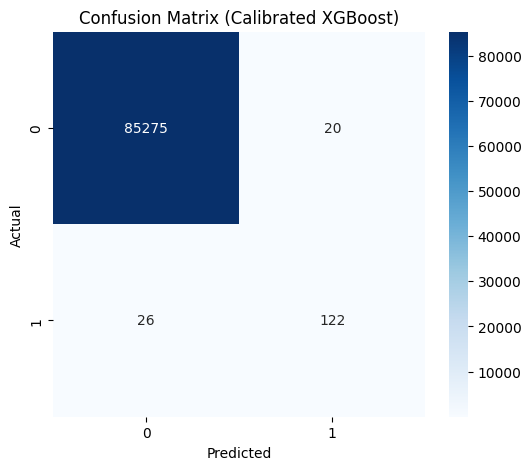


--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.82      0.84       148

    accuracy                           1.00     85443
   macro avg       0.93      0.91      0.92     85443
weighted avg       1.00      1.00      1.00     85443



In [47]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Convert decisions to numeric
y_pred = (y_prob_calibrated >= new_threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Calibrated XGBoost)")
plt.show()

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


The XGBoost model demonstrates achieves a high Precision of 0.86 and a Recall of 0.82. This indicates that the model is highly reliable such that when it flags a transaction as fraud, it is correct 86% of the time, while successfully capturing 82% of all actual fraudulent cases with very few false positives

To translate model performance into business impact, we generate a Final Results Table that applies our optimized threshold to the XGBoost predictions. This table maps each transaction to a specific action—BLOCK or APPROVE—and calculates the Cost Impact based on real-world financial consequences: the cost of a 'False Positive' (unnecessarily blocking a customer) versus a 'False Negative' (allowing a fraudulent transaction to pass).

In [48]:
# Final Results Table
results_xgb = X_test_pruned.copy()
results_xgb["fraud_probability"] = y_pred
results_xgb["decision"] = np.where(y_pred >= new_threshold, "BLOCK", "APPROVE")
results_xgb["true_class"] = y_test.values

# Add a column to see the cost impact of each row
results_xgb["cost_impact"] = 0
results_xgb.loc[(results_xgb["true_class"] == 0) & (results_xgb["decision"] == "BLOCK"), "cost_impact"] = C_FP
results_xgb.loc[(results_xgb["true_class"] == 1) & (results_xgb["decision"] == "APPROVE"), "cost_impact"] = C_FN

results_xgb.head(4)

,Amount,V4,V1,V22,V5,V11,V21,V19,V13,V8,...,V16,V17,V20,V12,V14,V10,fraud_probability,decision,true_class,cost_impact
186882,-0.203701,-1.102759,-2.537331,-2.167329,-2.105725,-1.612586,4.328165,-0.789047,0.406871,-3.543314,...,-0.947788,0.557331,-1.959611,0.635855,0.854371,0.112724,0,APPROVE,0,0
165754,-0.316167,0.417324,-0.250839,0.499501,1.204079,0.244248,0.133048,0.604366,-0.475202,-0.133535,...,-0.621563,-0.397771,-0.128120,0.418555,0.658159,-0.261170,0,APPROVE,0,0
235285,2.445431,1.670652,0.568980,-0.760732,-1.128945,0.520022,0.318037,-0.555301,-2.279548,0.161493,...,0.875849,-0.824311,1.039287,-0.251312,0.893064,0.099172,0,APPROVE,0,0
101271,-0.293298,0.381772,1.328892,-1.148959,0.238490,-1.431070,-0.379270,0.329519,-0.188827,-0.079962,...,0.919639,-0.475997,-0.050933,-0.578758,-0.236694,-0.267319,0,APPROVE,0,0


Feature importance

To gain transparency into the model's decision-making process, we perform Feature Importance Extraction on the trained XGBoost model. By ranking and visualizing the top 15 features, we can identify which specific variables—such as the PCA-transformed components or transaction amounts—carry the most weight in identifying fraudulent patterns, ensuring the model's logic aligns with known fraud indicators.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:33:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   Feature  Importance
0      V14    0.645622
1       V4    0.074950
2      V12    0.049734
3      V10    0.024308
4      V21    0.023213
5      V27    0.019816
6       V7    0.018522
7   Amount    0.018015
8      V11    0.016064
9      V17    0.015482
10     V20    0.014592
11      V8    0.013829
12     V13    0.013345
13      V5    0.008933
14     V16    0.008428


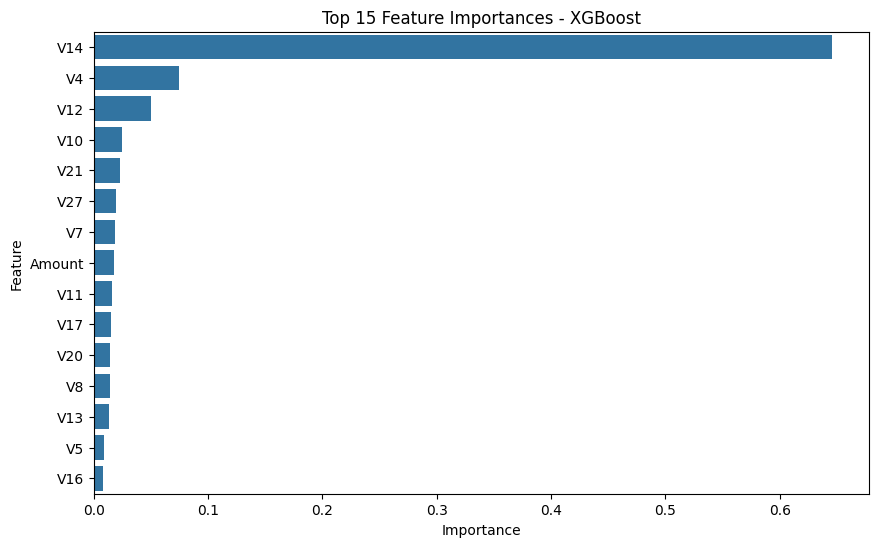

In [49]:

xgb_model.fit(X_train_pruned, y_train)

# Extract feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train_pruned.columns,
    "Importance": xgb_model.feature_importances_
})

# Sort descending
feature_importance = feature_importance.sort_values(by="Importance", ascending=False).reset_index(drop=True)

# View top features
print(feature_importance.head(15))

# Visualize
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


The feature importance analysis reveals that V14 is the dominant predictor, accounting for over 64% of the model's decision-making weight. Other significant drivers include V4 and V12, while the scaled Amount also ranks within the top 15, confirming that these specific PCA components and transaction values are the most critical signals for distinguishing fraud from legitimate activity.

Conclusion

This project demonstrates the development of a robust credit card fraud detection pipeline, transitioning from a simple baseline to a high-performance ensemble model. By addressing extreme class imbalance through class weighting and cost-optimized thresholding, we moved beyond standard accuracy to prioritize the real-world financial impact of our predictions.

Key Takeaways:

Model Comparison: While Logistic Regression served as a valuable baseline for feature pruning, it struggled with precision (0.56). In contrast, XGBoost proved far superior, achieving a Precision of 0.86 and a Recall of 0.82, effectively minimizing false alarms while maintaining high detection rates.

Feature Drivers: The analysis revealed that V14 is the single most significant indicator of fraud, followed by V4 and V12, highlighting the power of PCA components in uncovering hidden fraudulent patterns.

